# CIFAR-10 Federated Learning — Results Notebook

This notebook analyses results from **Algorithm 1** (PersFL) and baselines — **FedAvg**, **FedBN**, **FedProx**, **IFCA**, and **Ditto** — trained on a partitioned CIFAR-10 dataset.

---

## Part 1 — Hyperparameter Selection

| Section | Topic |
|---------|-------|
| 1.1 | Learning rate sweep across all algorithms and cluster counts *k* |
| 1.2 | Local update steps `R_local` sensitivity (Algorithm 1) |
| 1.3 | Candidate subset size *S* sensitivity (Algorithm 1) |
| 1.4 | FedProx proximal term μ sensitivity |
| 1.5 | Ditto proximal parameter λ sensitivity — joint sweep over λ and local dataset size *m* |
| 1.6 | Algorithm 1 vs TopK variants (K=4, K=8) — effect of candidate temperature |

## Part 2 — CIFAR-10 Rotated Experiments

| Section | Topic |
|---------|-------|
| 2.1 | Training curves and final accuracy across cluster counts *k* |
| 2.2 | Local dataset size *m* — all algorithms compared |
| 2.3 | Within-cluster rotation spread σ |


In [314]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

LRATE_BASE      = Path("results/cnn_cifar10_lrate")
DITTO_LMBD_BASE = Path("results/cnn_cifar10_ditto_lmbd")

LRATE_ALGOS = ["Algorithm1", "FedBN", "FedProx", "IFCA", "Ditto"]

ALGO_STYLE = {
    "Algorithm1": dict(linestyle="-",  color="#1f77b4"),
    "Algorithm1_TopK": dict(linestyle="--",  color="#1f77b4"),
    "FedAvg":     dict(linestyle="-",  color="k"),
    "FedBN":      dict(linestyle="--", color="#ff7f0e"),
    "FedProx":    dict(linestyle=":",  color="#2ca02c"),
    "IFCA":       dict(linestyle="-.", color="#d62728"),
    "Ditto":      dict(linestyle="-",  color="#9467bd"),
}

def load_results(base, algos):
    frames = []
    for algo in algos:
        p = base / algo
        if not p.exists():
            continue
        for f in sorted(p.glob("*.csv")):
            df = pd.read_csv(f)
            df["algo"] = algo
            frames.append(df)
    return pd.concat(frames, ignore_index=True)

def get_final(df, group_cols):
    """Last recorded iteration per group."""
    return df.loc[df.groupby(group_cols)["iter"].idxmax()].reset_index(drop=True)

def get_best(df, group_cols, sweep_col):
    """Row with highest final accuracy per group, maximised over sweep_col."""
    final = get_final(df, group_cols + [sweep_col])
    idx = final.groupby(group_cols)["accuracy"].idxmax()
    return final.loc[idx].reset_index(drop=True)

---

## Part 1 — Hyperparameter Selection

### Learning Rate Sensitivity (per algorithm)

Each algorithm is evaluated across a grid of learning rates and cluster counts *k*. Curves show test accuracy vs. communication round; each line corresponds to one learning rate value. This reveals how sensitive each method is to the step-size choice and helps identify a robust operating range.

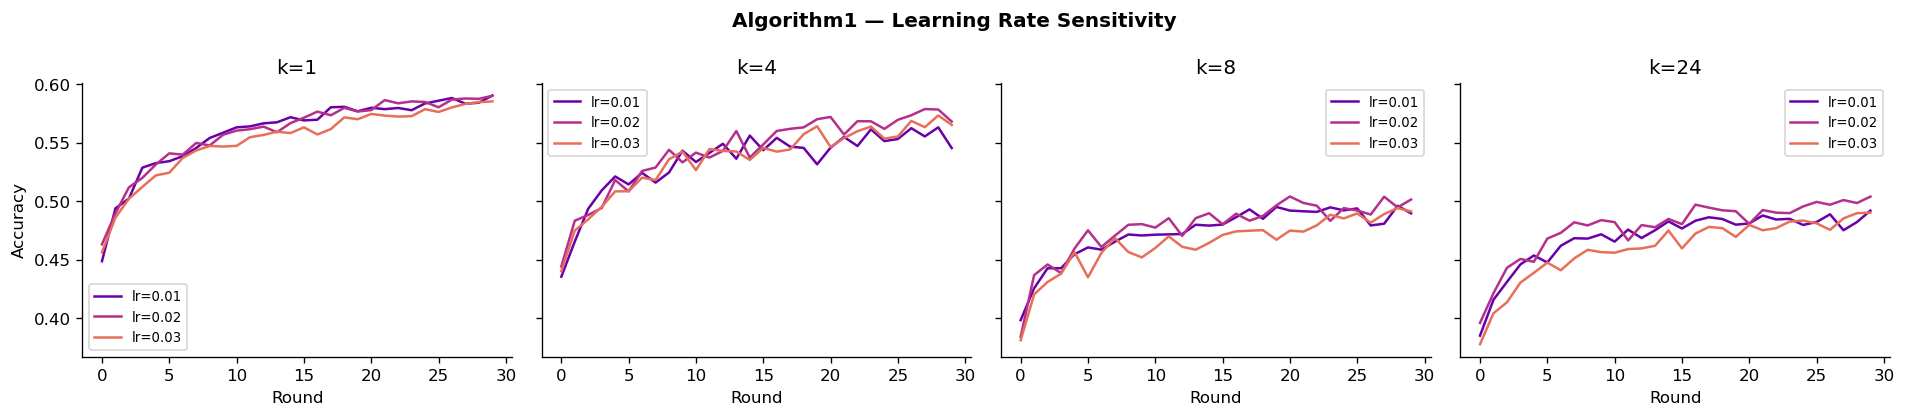

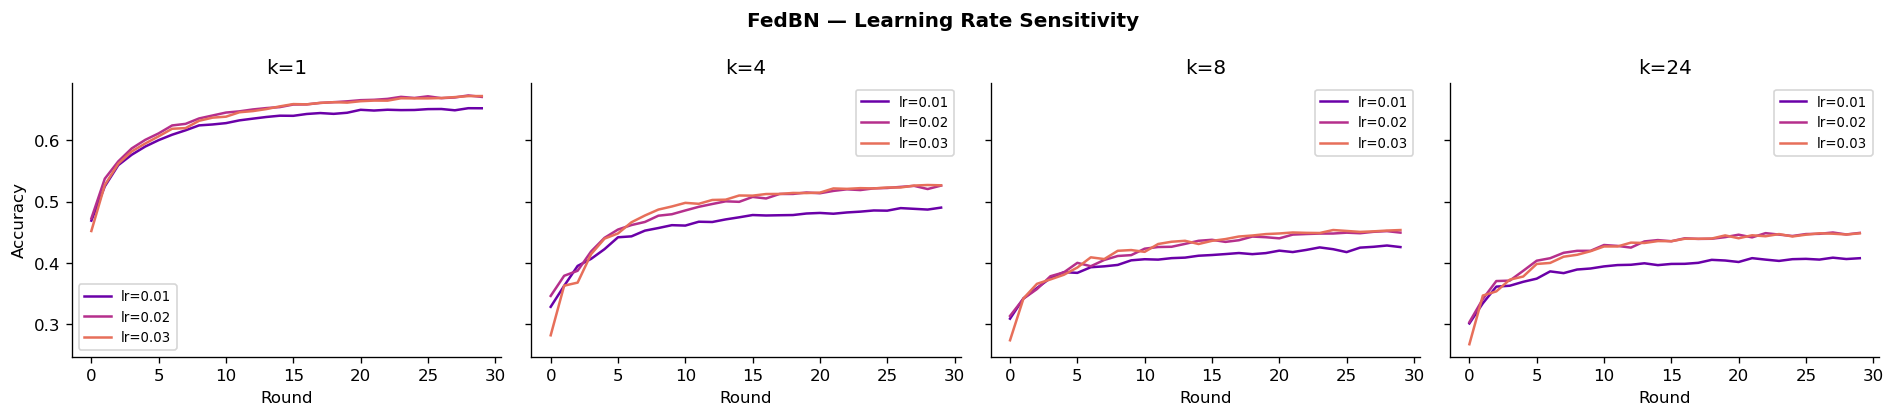

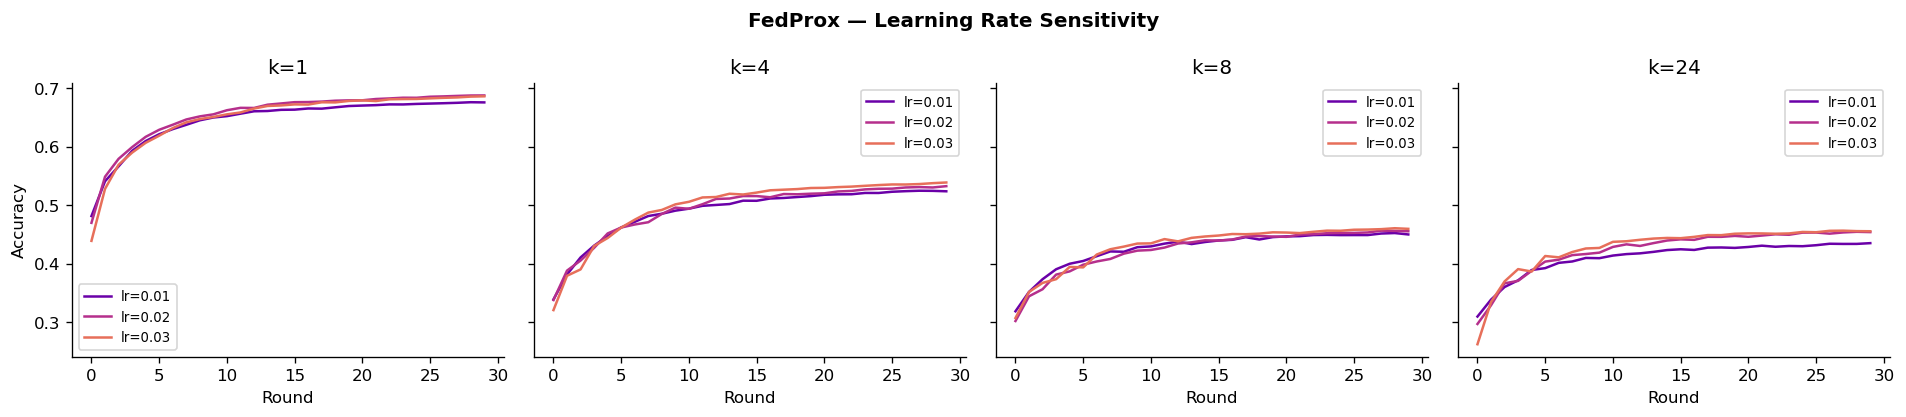

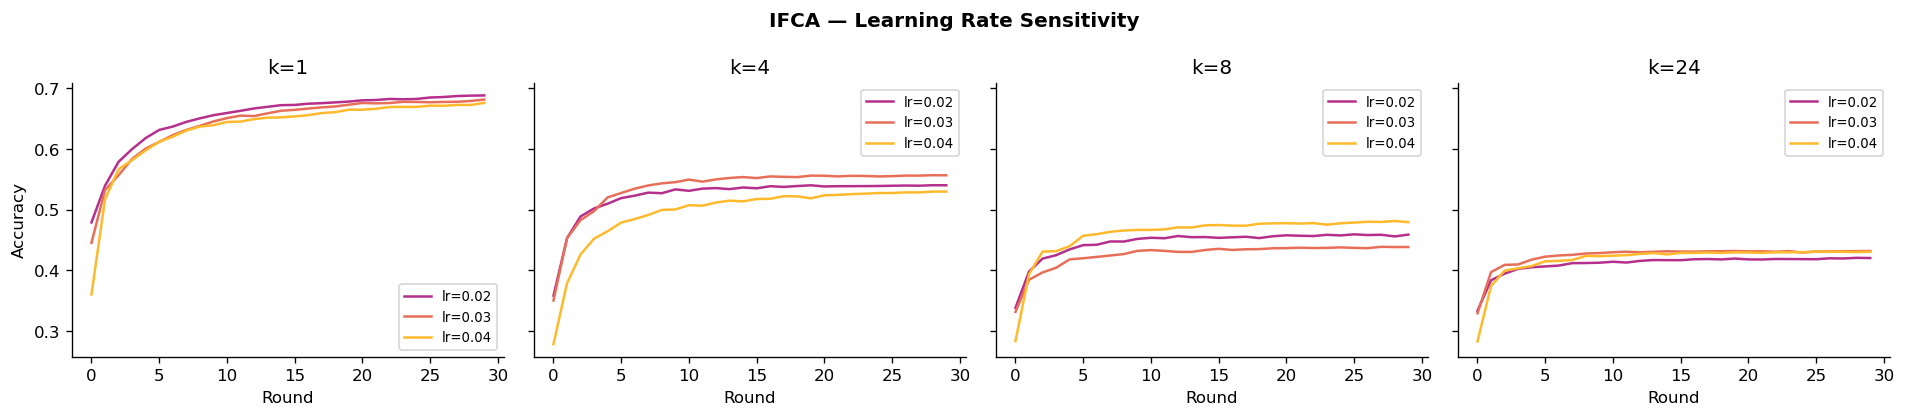

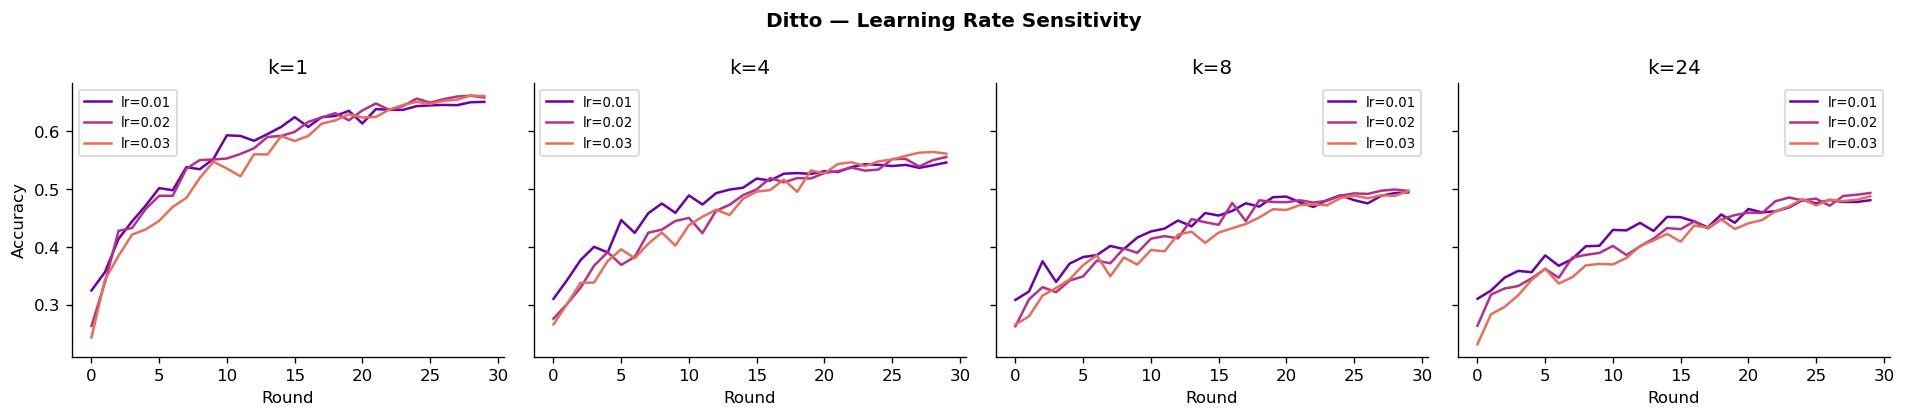

In [248]:
# ── Section 1: Learning Rate Sensitivity (per algo) ──────────────────────────
lrate_data = load_results(LRATE_BASE, LRATE_ALGOS)
clusters   = sorted(lrate_data["data_n_clusters"].unique())
lrates     = sorted(lrate_data["algo_lrate"].unique())
lr_colors  = cm.plasma(np.linspace(0.2, 0.85, len(lrates)))

for algo in LRATE_ALGOS:
    sub = lrate_data[lrate_data["algo"] == algo]
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, len(clusters), figsize=(4 * len(clusters), 3.5), sharey=True)
    if len(clusters) == 1:
        axes = [axes]

    for ax, nc in zip(axes, clusters):
        for lr, color in zip(lrates, lr_colors):
            curve = sub[
                (sub["data_n_clusters"] == nc) & (sub["algo_lrate"] == lr)
            ].sort_values("iter")
            if not curve.empty:
                ax.plot(curve["iter"], curve["accuracy"], color=color, label=f"lr={lr}")
        ax.set_title(f"k={nc}")
        ax.set_xlabel("Round")
        ax.legend(fontsize=8)

    axes[0].set_ylabel("Accuracy")
    fig.suptitle(f"{algo} — Learning Rate Sensitivity", fontweight="bold")
    plt.tight_layout()
    plt.show()

In [249]:
# Summary table: final accuracy by algo × k × lrate
final_lr = get_final(lrate_data, ["algo", "data_n_clusters", "algo_lrate"])
tbl = final_lr[["algo", "data_n_clusters", "algo_lrate", "accuracy"]].copy()
tbl.columns = ["Algo", "k", "lrate", "Acc"]
tbl["Acc"] = tbl["Acc"].round(4)
pivot = tbl.pivot_table(index=["Algo", "k"], columns="lrate", values="Acc")
print("Final accuracy by algo × k × lrate")
display(pivot)

Final accuracy by algo × k × lrate


lrate            0.01    0.02    0.03    0.04
Algo       k                                 
Algorithm1 1   0.5903  0.5900  0.5852     NaN
           4   0.5454  0.5680  0.5652     NaN
           8   0.4896  0.5014  0.4912     NaN
           24  0.4919  0.5039  0.4902     NaN
Ditto      1   0.6511  0.6589  0.6613     NaN
           4   0.5463  0.5558  0.5615     NaN
           8   0.4945  0.4972  0.4968     NaN
           24  0.4810  0.4935  0.4878     NaN
FedBN      1   0.6524  0.6710  0.6724     NaN
           4   0.4903  0.5263  0.5267     NaN
           8   0.4259  0.4495  0.4537     NaN
           24  0.4078  0.4490  0.4484     NaN
FedProx    1   0.6759  0.6878  0.6863     NaN
           4   0.5237  0.5325  0.5388     NaN
           8   0.4498  0.4552  0.4594     NaN
           24  0.4349  0.4538  0.4552     NaN
IFCA       1      NaN  0.6882  0.6814  0.6760
           4      NaN  0.5402  0.5567  0.5299
           8      NaN  0.4590  0.4386  0.4795
           24     NaN  0.4204  0.4321  0.4308

### Local Update Steps `R_local` Sensitivity (Algorithm 1)

`R_local` controls how many local gradient steps Algorithm 1 performs on the selected candidate's data before updating the shared model. Larger values exploit the chosen data generator more aggressively but increase local compute per round. This section plots accuracy vs. communication round for each `R_local` value across cluster counts *k*.

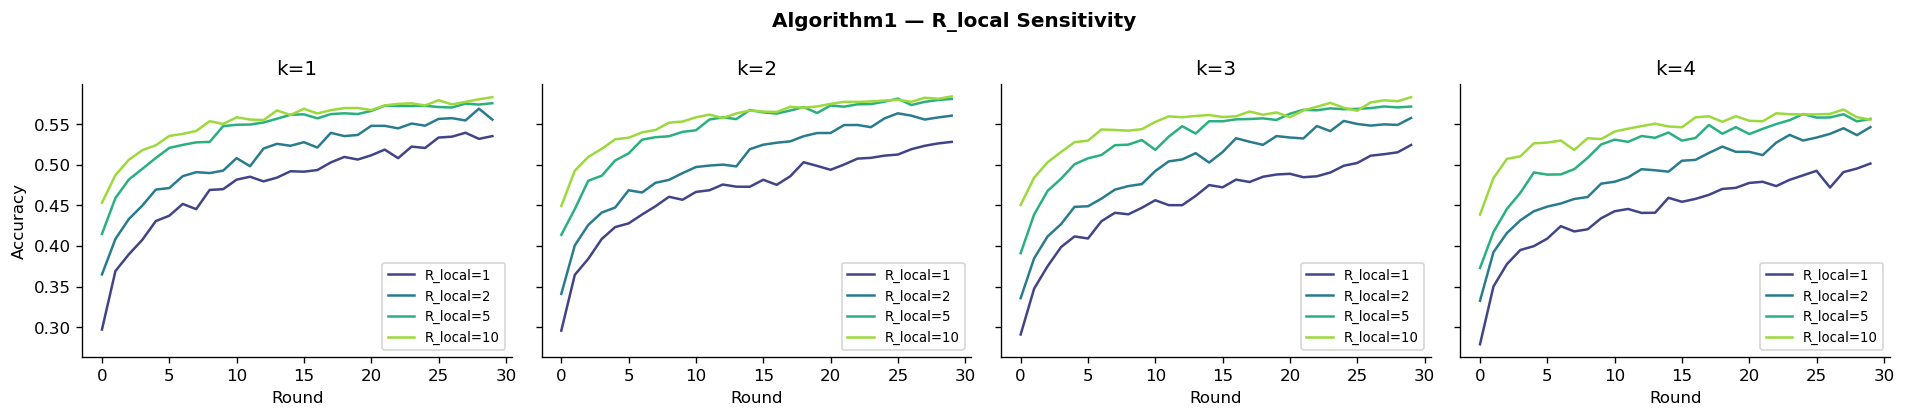

In [226]:
data     = load_results(Path("results/cnn_cifar10_rlocal"), ["Algorithm1"])
vals     = sorted(data["algo_R_local"].unique())
colors   = cm.viridis(np.linspace(0.2, 0.85, len(vals)))
clusters = sorted(data["data_n_clusters"].unique())

for algo in ["Algorithm1"]:
    sub = data[data["algo"] == algo]
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, len(clusters), figsize=(4 * len(clusters), 3.5), sharey=True)
    if len(clusters) == 1:
        axes = [axes]

    for ax, nc in zip(axes, clusters):
        for R_local, color in zip(vals, colors):
            curve = sub[
                (sub["data_n_clusters"] == nc) & (sub["algo_R_local"] == R_local)
            ].sort_values("iter")
            if not curve.empty:
                ax.plot(curve["iter"], curve["accuracy"], color=color, label=f"R_local={int(R_local)}")
        ax.set_title(f"k={nc}")
        ax.set_xlabel("Round")
        ax.legend(fontsize=8)

    axes[0].set_ylabel("Accuracy")
    fig.suptitle(f"{algo} — R_local Sensitivity", fontweight="bold")
    plt.tight_layout()
    plt.show()

### Candidate Subset Size *S* Sensitivity (Algorithm 1)

*S* is the number of data generators randomly probed at each communication round — the core exploration parameter of Algorithm 1. A larger *S* increases the probability of finding a beneficial neighbour but raises communication cost linearly with *S*. This section shows how accuracy trajectories change with *S* across cluster counts *k*, helping identify a good trade-off between exploration and overhead.

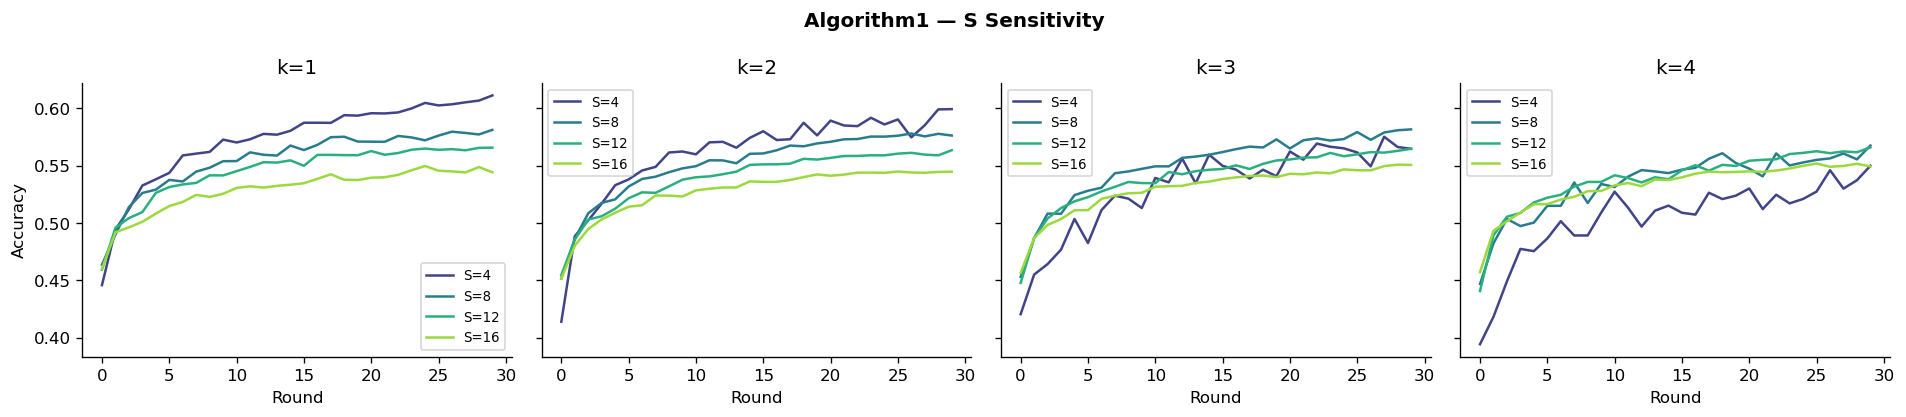

In [227]:
data     = load_results(Path("results/cnn_cifar10_S"), ["Algorithm1"])
vals     = sorted(data["algo_S"].unique())
colors   = cm.viridis(np.linspace(0.2, 0.85, len(vals)))
clusters = sorted(data["data_n_clusters"].unique())

for algo in ["Algorithm1"]:
    sub = data[data["algo"] == algo]
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, len(clusters), figsize=(4 * len(clusters), 3.5), sharey=True)
    if len(clusters) == 1:
        axes = [axes]

    for ax, nc in zip(axes, clusters):
        for S, color in zip(vals, colors):
            curve = sub[
                (sub["data_n_clusters"] == nc) & (sub["algo_S"] == S)
            ].sort_values("iter")
            if not curve.empty:
                ax.plot(curve["iter"], curve["accuracy"], color=color, label=f"S={int(S)}")
        ax.set_title(f"k={nc}")
        ax.set_xlabel("Round")
        ax.legend(fontsize=8)

    axes[0].set_ylabel("Accuracy")
    fig.suptitle(f"{algo} — S Sensitivity", fontweight="bold")
    plt.tight_layout()
    plt.show()

### FedProx Proximal Term μ Sensitivity

FedProx augments the local objective with a proximal penalty $\frac{\mu}{2}\|\mathbf{w} - \mathbf{w}^t\|^2$ that pulls each client's update toward the global model received at round $t$. The scalar $\mu \geq 0$ controls the strength of this regularisation:

- **μ = 0** recovers standard FedAvg (no proximal constraint).
- **Large μ** keeps local updates close to the global model, reducing client drift at the cost of under-exploiting local data.

This section sweeps $\mu \in \{0,\, 0.01,\, 0.1,\, 1.0\}$ for FedProx across cluster counts $k \in \{1, 2, 3, 4\}$ to quantify how the proximal term trades off personalisation against stability.

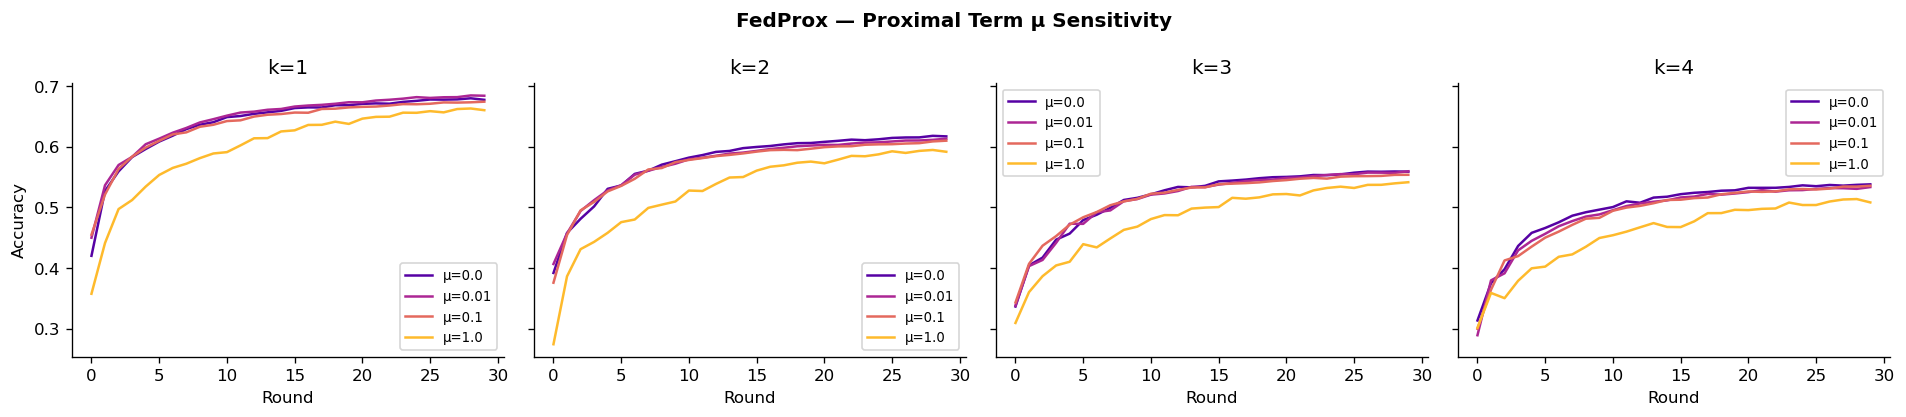

FedProx final accuracy by k × μ


μ,0.00,0.01,0.10,1.00
k,,,,
1,0.6774,0.6841,0.6743,0.6603
2,0.6170,0.6132,0.6099,0.5916
3,0.5588,0.5595,0.5537,0.5414
4,0.5379,0.5334,0.5356,0.5081


In [228]:
# ── Section 1.5: FedProx μ Sensitivity ───────────────────────────────────────
FEDPROX_MU_BASE = Path("results/cnn_cifar10_fedprox_mu")

mu_data     = load_results(FEDPROX_MU_BASE, ["FedProx"])
mu_vals     = sorted(mu_data["algo_mu"].unique())
clusters_mu = sorted(mu_data["data_n_clusters"].unique())
mu_colors   = cm.plasma(np.linspace(0.15, 0.85, len(mu_vals)))

# ── Training curves: one subplot per k ───────────────────────────────────────
fig, axes = plt.subplots(1, len(clusters_mu), figsize=(4 * len(clusters_mu), 3.5), sharey=True)
if len(clusters_mu) == 1:
    axes = [axes]

for ax, nc in zip(axes, clusters_mu):
    for mu, color in zip(mu_vals, mu_colors):
        curve = mu_data[
            (mu_data["data_n_clusters"] == nc) & (mu_data["algo_mu"] == mu)
        ].sort_values("iter")
        if not curve.empty:
            ax.plot(curve["iter"], curve["accuracy"], color=color, label=f"μ={mu}")
    ax.set_title(f"k={nc}")
    ax.set_xlabel("Round")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Accuracy")
fig.suptitle("FedProx — Proximal Term μ Sensitivity", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Summary table: final accuracy by k × μ ───────────────────────────────────
final_mu = get_final(mu_data, ["data_n_clusters", "algo_mu"])
tbl_mu = final_mu[["data_n_clusters", "algo_mu", "accuracy"]].copy()
tbl_mu.columns = ["k", "μ", "Acc"]
tbl_mu["Acc"] = tbl_mu["Acc"].round(4)
pivot_mu = tbl_mu.pivot_table(index="k", columns="μ", values="Acc")
print("FedProx final accuracy by k × μ")
display(pivot_mu)

### Ditto Proximal Parameter λ Sensitivity

Ditto augments each client's local objective with a proximal term $\frac{\lambda}{2}\|\mathbf{w}^i - \mathbf{w}^g\|^2$ that regularises the personalised model $\mathbf{w}^i$ toward the global model $\mathbf{w}^g$. The scalar $\lambda \geq 0$ controls how strongly the personal model is anchored to the global solution:

- **λ = 0** — personalised model is unconstrained (pure local training).
- **Large λ** — personalised model is pulled close to the global model, reducing personalisation.

This section sweeps $\lambda \in \{0.01,\, 0.1,\, 1.0,\, 10.0\}$ and sample size $m \in \{50,\, 100,\, 200,\, 500\}$ across cluster counts $k$ to quantify how the optimal $\lambda$ depends on the amount of local data.

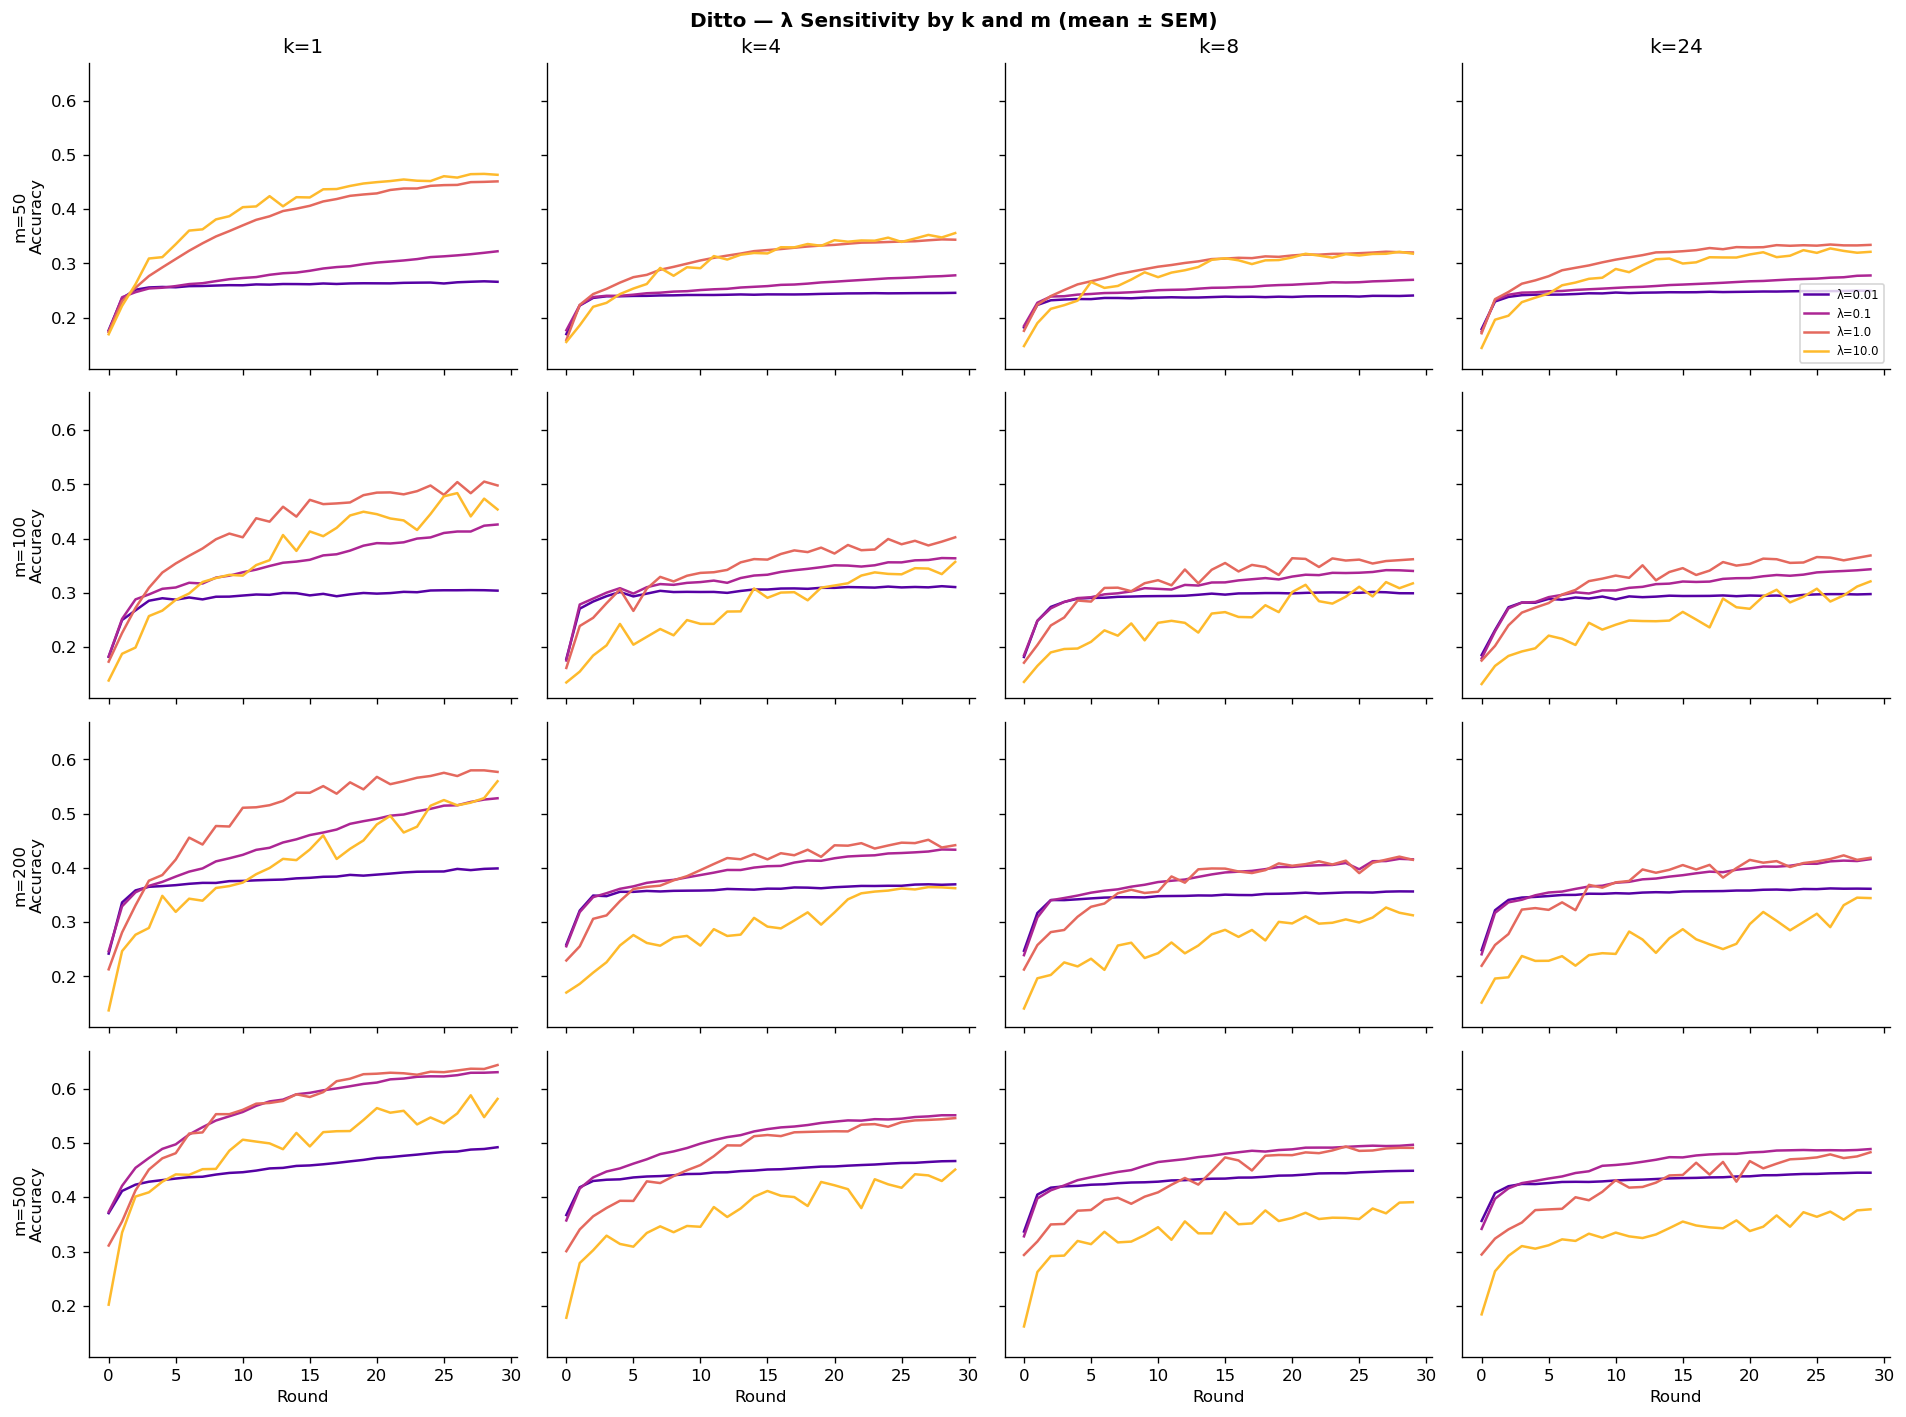

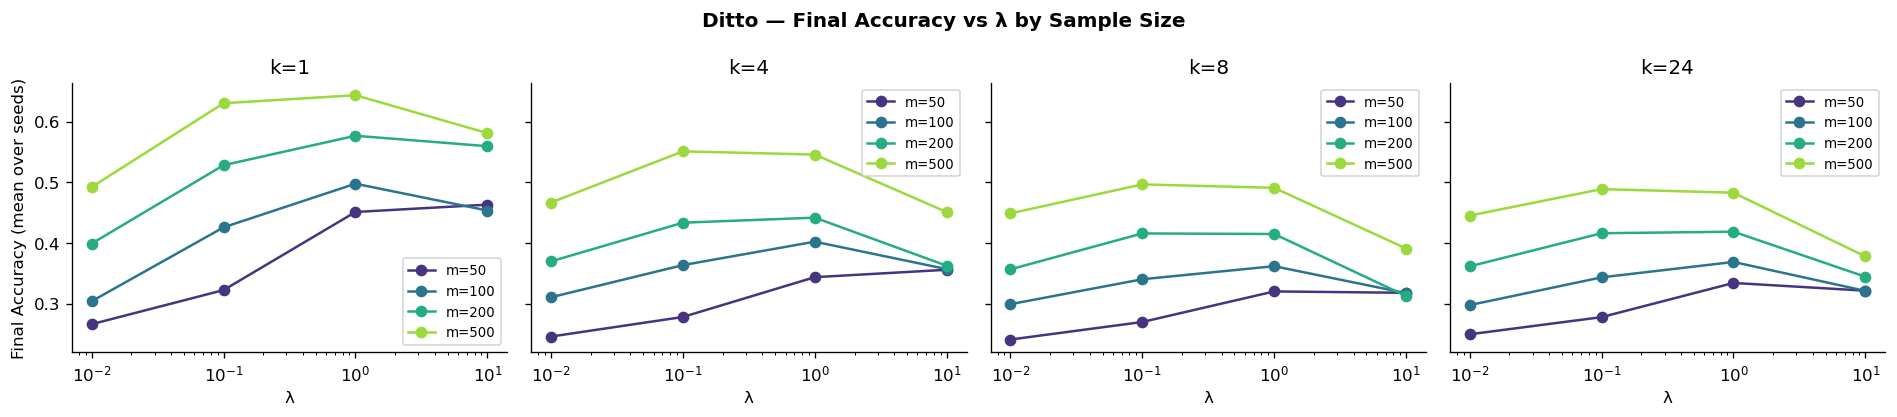


Ditto final accuracy (mean over seeds) — k=1


λ,0.01,0.10,1.00,10.00
m,,,,
50,0.2660,0.3223,0.4512,0.4633
100,0.3039,0.4259,0.4979,0.4536
200,0.3990,0.5284,0.5770,0.5598
500,0.4923,0.6307,0.6439,0.5814



Ditto final accuracy (mean over seeds) — k=4


λ,0.01,0.10,1.00,10.00
m,,,,
50,0.2457,0.2780,0.3437,0.3559
100,0.3105,0.3635,0.4023,0.3569
200,0.3697,0.4335,0.4419,0.3625
500,0.4668,0.5513,0.5460,0.4511



Ditto final accuracy (mean over seeds) — k=8


λ,0.01,0.10,1.00,10.00
m,,,,
50,0.2407,0.2697,0.3201,0.3179
100,0.2990,0.3402,0.3618,0.3173
200,0.3565,0.4158,0.4149,0.3126
500,0.4489,0.4967,0.4911,0.3910



Ditto final accuracy (mean over seeds) — k=24


λ,0.01,0.10,1.00,10.00
m,,,,
50,0.2494,0.2777,0.3341,0.3213
100,0.2975,0.3433,0.3688,0.3210
200,0.3615,0.4162,0.4187,0.3443
500,0.4453,0.4890,0.4830,0.3778


In [305]:
# ── Section 1.6: Ditto λ Sensitivity (effect of m) ───────────────────────────
import re as _re

_DITTO_BASE = Path("results/cnn_cifar10_ditto")
_DITTO_PAT  = _re.compile(r"cnn_cifar10_c(\d+)_m(\d+)_lmbd([0-9.]+)_seed(\d+)\.csv")

ditto_frames = []
for f in sorted(_DITTO_BASE.glob("*.csv")):
    match = _DITTO_PAT.search(f.name)
    if not match:
        continue
    nc   = int(match.group(1))
    m_sz = int(match.group(2))
    lmbd = float(match.group(3))
    seed = int(match.group(4))
    df   = pd.read_csv(f)
    df["data_n_clusters"] = nc
    df["m"]               = m_sz
    df["algo_lmbd"]       = lmbd
    df["seed"]            = seed
    df["algo"]            = "Ditto"
    ditto_frames.append(df)

ditto_data     = pd.concat(ditto_frames, ignore_index=True)
lmbd_vals      = sorted(ditto_data["algo_lmbd"].unique())
m_vals         = sorted(ditto_data["m"].unique())
clusters_ditto = sorted(ditto_data["data_n_clusters"].unique())

lmbd_colors = cm.plasma(np.linspace(0.15, 0.85, len(lmbd_vals)))
m_colors    = cm.viridis(np.linspace(0.15, 0.85, len(m_vals)))

# ── Training curves: rows = m, cols = k, lines = λ ───────────────────────────
nrows, ncols = len(m_vals), len(clusters_ditto)
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4 * ncols, 3 * nrows),
                         sharey=True, sharex=True)
axes = np.array(axes).reshape(nrows, ncols)

for row, m_sz in enumerate(m_vals):
    for col, nc in enumerate(clusters_ditto):
        ax = axes[row, col]
        for lmbd, color in zip(lmbd_vals, lmbd_colors):
            sub = ditto_data[
                (ditto_data["data_n_clusters"] == nc) &
                (ditto_data["m"] == m_sz) &
                (ditto_data["algo_lmbd"] == lmbd)
            ]
            if sub.empty:
                continue
            stats_d = (
                sub.groupby("iter")["accuracy"]
                .agg(mean="mean", std="std", n="count")
                .reset_index()
            )
            stats_d["sem"] = stats_d["std"] / stats_d["n"].pow(0.5)
            stats_d = stats_d.sort_values("iter")
            ax.plot(stats_d["iter"], stats_d["mean"], color=color, label=f"λ={lmbd}")
            ax.fill_between(
                stats_d["iter"],
                stats_d["mean"] - stats_d["sem"],
                stats_d["mean"] + stats_d["sem"],
                alpha=0.2, color=color,
            )
        if row == 0:
            ax.set_title(f"k={nc}")
        if col == 0:
            ax.set_ylabel(f"m={m_sz}\nAccuracy")
        if row == nrows - 1:
            ax.set_xlabel("Round")

axes[0, -1].legend(fontsize=7, loc="lower right")
fig.suptitle("Ditto — λ Sensitivity by k and m (mean ± SEM)", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Final accuracy vs λ: one subplot per k, lines = m ────────────────────────
ditto_final = get_final(ditto_data, ["data_n_clusters", "m", "algo_lmbd", "seed"])
ditto_agg   = (
    ditto_final
    .groupby(["data_n_clusters", "m", "algo_lmbd"])["accuracy"]
    .mean()
    .reset_index()
)

fig2, axes2 = plt.subplots(1, len(clusters_ditto),
                            figsize=(4 * len(clusters_ditto), 3.5), sharey=True)
if len(clusters_ditto) == 1:
    axes2 = [axes2]

for ax, nc in zip(axes2, clusters_ditto):
    sub = ditto_agg[ditto_agg["data_n_clusters"] == nc]
    for m_sz, color in zip(m_vals, m_colors):
        row = sub[sub["m"] == m_sz].sort_values("algo_lmbd")
        if row.empty:
            continue
        ax.plot(row["algo_lmbd"], row["accuracy"], marker="o", color=color,
                label=f"m={m_sz}")
    ax.set_xscale("log")
    ax.set_title(f"k={nc}")
    ax.set_xlabel("λ")
    ax.legend(fontsize=8)

axes2[0].set_ylabel("Final Accuracy (mean over seeds)")
fig2.suptitle("Ditto — Final Accuracy vs λ by Sample Size", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Summary table: final accuracy by m × λ, one table per k ──────────────────
ditto_agg["Acc"] = ditto_agg["accuracy"].round(4)
for nc in clusters_ditto:
    sub = ditto_agg[ditto_agg["data_n_clusters"] == nc]
    pivot = sub.pivot_table(index="m", columns="algo_lmbd", values="Acc")
    pivot.index.name   = "m"
    pivot.columns.name = "λ"
    print(f"\nDitto final accuracy (mean over seeds) — k={nc}")
    display(pivot)


### Algorithm1 vs TopK (K=4, K=8) -  Effect of temperature 

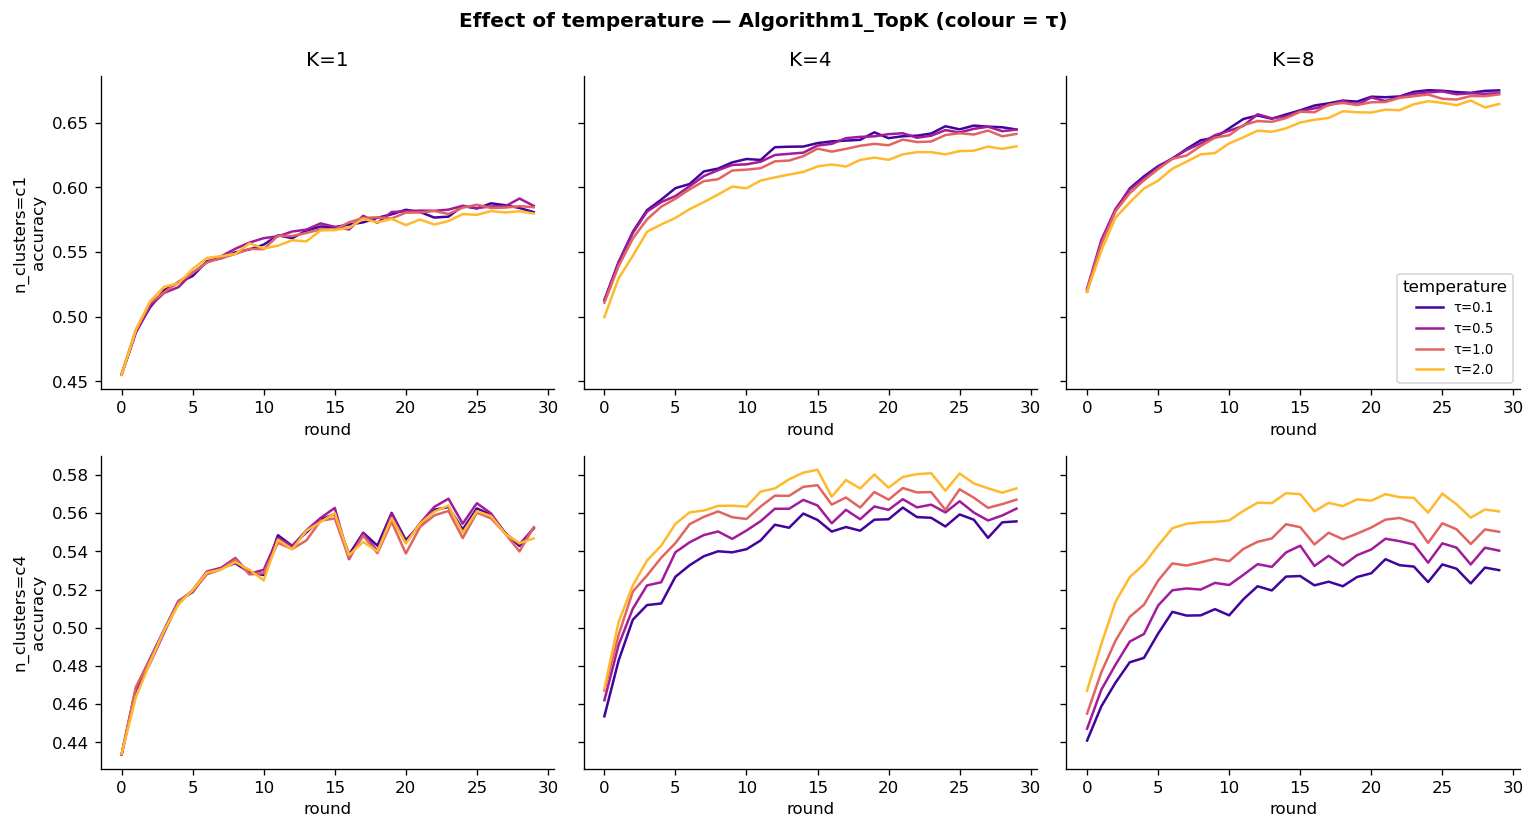

In [262]:
# ── Effect of temperature — TopK, c1 vs c4, K∈{1,4,8} ───────────────────────
import re
from pathlib import Path

TOPK_DIRS = {
    "c1": Path("results/cnn_cifar10_topk_c1"),
    "c4": Path("results/cnn_cifar10_topk_c4"),
}
PAT_TOPK = re.compile(r"cnn_cifar10_K(\d+)_temp([0-9.]+)_seed(\d+)\.csv")

K_VALS   = [1, 4, 8]
TEMP_VALS = [0.1, 0.5, 1.0, 2.0]
temp_colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(TEMP_VALS)))

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey="row")

for row, (nc_label, dir_path) in enumerate(TOPK_DIRS.items()):
    # load all files into a dict keyed by (K, temp) -> [accuracy curves]
    curves = {}
    for f in sorted(dir_path.glob("*.csv")):
        m = PAT_TOPK.search(f.name)
        if not m:
            continue
        K, temp = int(m.group(1)), float(m.group(2))
        df = pd.read_csv(f)
        curves.setdefault((K, temp), []).append(df["accuracy"].values)

    for col, K in enumerate(K_VALS):
        ax = axes[row, col]
        for temp, color in zip(TEMP_VALS, temp_colors):
            runs = curves.get((K, temp))
            if not runs:
                continue
            # mean across seeds (currently 1 seed)
            acc = np.mean(runs, axis=0)
            ax.plot(acc, color=color, label=f"τ={temp}")
        ax.set_title(f"K={K}" if row == 0 else "")
        ax.set_xlabel("round")
        if col == 0:
            ax.set_ylabel(f"n_clusters={nc_label}\naccuracy")
        if row == 0 and col == 2:
            ax.legend(fontsize=8, title="temperature")

fig.suptitle("Effect of temperature — Algorithm1_TopK (colour = τ)", fontweight="bold")
fig.tight_layout()
plt.show()


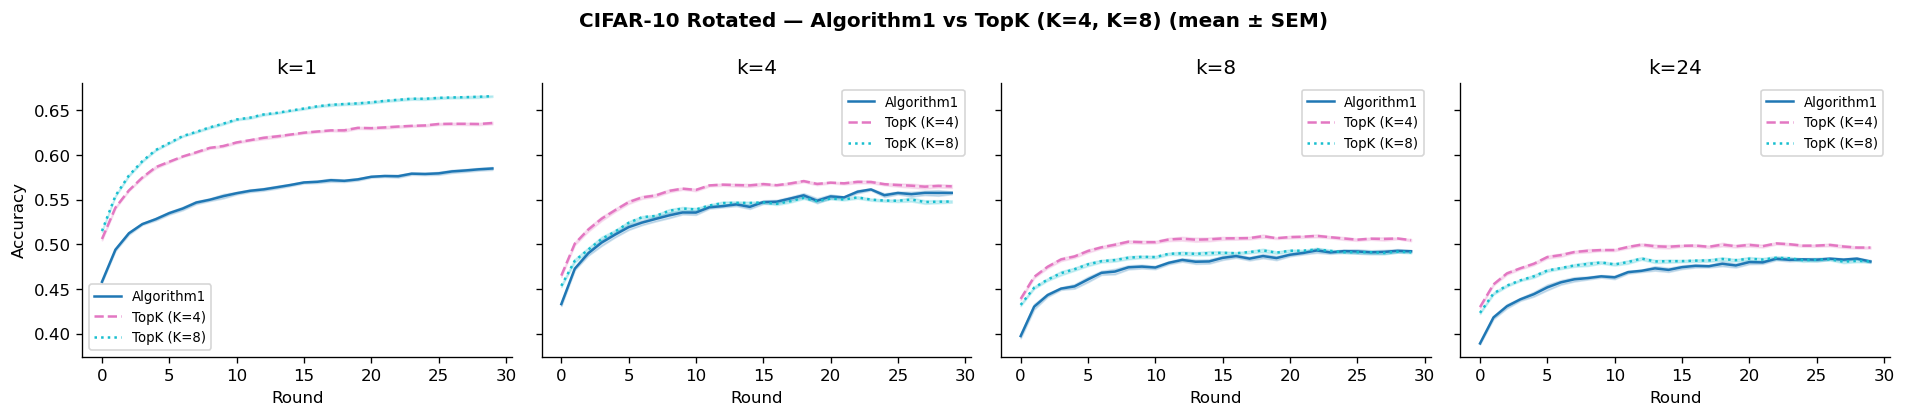

Final accuracy (mean ± SEM) — Algorithm1 vs TopK


,k=1,k=4,k=8,k=24
algo,,,,
Algorithm1,0.5848 ± 0.0016,0.5575 ± 0.0015,0.4922 ± 0.0014,0.4807 ± 0.0016
TopK (K=4),0.6357 ± 0.0014,0.5648 ± 0.0018,0.5046 ± 0.0012,0.4963 ± 0.0011
TopK (K=8),0.6658 ± 0.0008,0.5479 ± 0.0012,0.4910 ± 0.0011,0.4808 ± 0.0014


In [303]:
# ── CIFAR-10 Rotated — Algorithm1 vs TopK (K=4, K=8) ───────────────────────
import re as _re_topk

TOPK_NC_BASE = Path("results/cnn_cifar10_topk_nclusters")
_PAT_NC = _re_topk.compile(r"cnn_cifar10_K(\d+)_nc(\d+)_seed(\d+)\.csv")

K_COMPARE = [4, 8]

# Load TopK curves
_topk_frames = []
for _f in sorted(TOPK_NC_BASE.glob("*.csv")):
    _m = _PAT_NC.search(_f.name)
    if not _m:
        continue
    _K, _nc = int(_m.group(1)), int(_m.group(2))
    if _K not in K_COMPARE:
        continue
    _df = pd.read_csv(_f)
    _df["algo"] = f"TopK (K={_K})"
    _df["data_n_clusters"] = _nc
    _topk_frames.append(_df[["iter", "accuracy", "algo", "data_n_clusters"]])

_algo1 = rot_data[rot_data["algo"] == "Algorithm1"][["iter", "accuracy", "algo", "data_n_clusters"]].copy()
_combined = pd.concat([_algo1] + _topk_frames, ignore_index=True)

_algos_cmp = ["Algorithm1"] + [f"TopK (K={K})" for K in K_COMPARE]
_cmp_stats = (
    _combined
    .groupby(["algo", "data_n_clusters", "iter"])["accuracy"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)
_cmp_stats["sem"] = _cmp_stats["std"] / _cmp_stats["n"].pow(0.5)

_CMP_STYLE = {
    "Algorithm1":  dict(linestyle="-",  color="#1f77b4"),
    "TopK (K=4)":  dict(linestyle="--", color="#e377c2"),
    "TopK (K=8)":  dict(linestyle=":",  color="#17becf"),
}

_clusters_cmp = sorted(_combined["data_n_clusters"].unique())
fig, axes = plt.subplots(1, len(_clusters_cmp), figsize=(4 * len(_clusters_cmp), 3.5), sharey=True)
if len(_clusters_cmp) == 1:
    axes = [axes]

for ax, nc in zip(axes, _clusters_cmp):
    for algo in _algos_cmp:
        sub = _cmp_stats[
            (_cmp_stats["algo"] == algo) & (_cmp_stats["data_n_clusters"] == nc)
        ].sort_values("iter")
        if sub.empty:
            continue
        style = _CMP_STYLE[algo]
        ax.plot(sub["iter"], sub["mean"], label=algo, **style)
        ax.fill_between(
            sub["iter"],
            sub["mean"] - sub["sem"],
            sub["mean"] + sub["sem"],
            alpha=0.2, color=style["color"],
        )
    ax.set_title(f"k={nc}")
    ax.set_xlabel("Round")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Accuracy")
fig.suptitle("CIFAR-10 Rotated — Algorithm1 vs TopK (K=4, K=8) (mean \u00b1 SEM)", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Final-round summary table ─────────────────────────────────────────────────
_max_iter_cmp = _cmp_stats["iter"].max()
_final_cmp = _cmp_stats[_cmp_stats["iter"] == _max_iter_cmp].copy()
_final_cmp["acc"] = _final_cmp.apply(lambda r: f"{r['mean']:.4f} \u00b1 {r['sem']:.4f}", axis=1)
_pivot_cmp = _final_cmp.pivot_table(
    index="algo", columns="data_n_clusters", values="acc", aggfunc="first"
)
_pivot_cmp.columns = [f"k={c}" for c in _pivot_cmp.columns]
_pivot_cmp = _pivot_cmp.reindex(_algos_cmp)
print("Final accuracy (mean \u00b1 SEM) — Algorithm1 vs TopK")
display(_pivot_cmp)


---

## Part 2 — CIFAR-10 Rotated Experiments

### CIFAR-10 Rotated Dataset

Clients are grouped into $k \in \{1, 2, 3, 4\}$ clusters, each associated with a fixed image rotation angle. All images within a client are rotated accordingly, inducing distributional shifts across clusters while keeping the label space unchanged.

Results are averaged over 10 random seeds; shaded bands show one standard error of the mean (SEM). This setting tests each algorithm's ability to handle geometric heterogeneity — a non-label-based form of data shift that is invisible to clustering strategies that rely on label distributions alone.

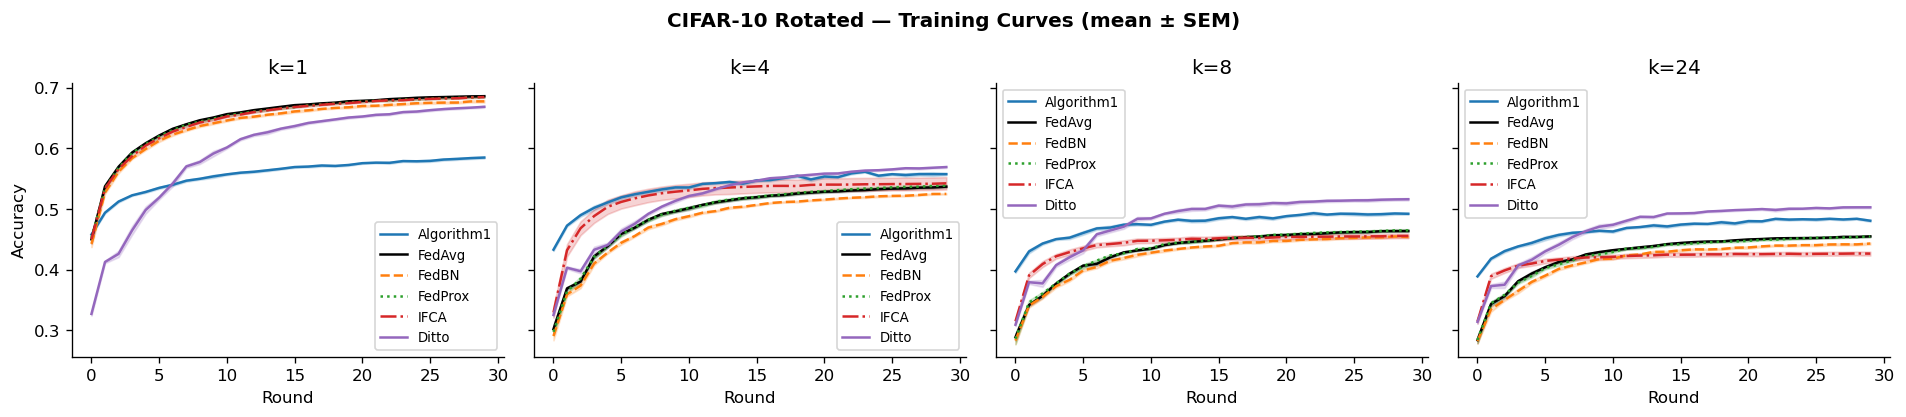

Final accuracy (mean ± SEM) — CIFAR-10 Rotated


,k=1,k=4,k=8,k=24
algo,,,,
Algorithm1,0.5848 ± 0.0016,0.5575 ± 0.0015,0.4922 ± 0.0014,0.4807 ± 0.0016
Ditto,0.6685 ± 0.0014,0.5692 ± 0.0014,0.5161 ± 0.0020,0.5028 ± 0.0015
FedAvg,0.6860 ± 0.0012,0.5368 ± 0.0019,0.4637 ± 0.0014,0.4549 ± 0.0012
FedBN,0.6775 ± 0.0019,0.5249 ± 0.0010,0.4541 ± 0.0017,0.4431 ± 0.0016
FedProx,0.6847 ± 0.0012,0.5386 ± 0.0016,0.4647 ± 0.0019,0.4548 ± 0.0010
IFCA,0.6846 ± 0.0012,0.5424 ± 0.0102,0.4556 ± 0.0035,0.4264 ± 0.0032


In [302]:
ROTATED_BASE  = Path("results/cnn_cifar10_rotated")
ROTATED_ALGOS = ["Algorithm1", "FedAvg", "FedBN", "FedProx", "IFCA", "Ditto"]

rot_data = load_results(ROTATED_BASE, ROTATED_ALGOS)
clusters_rot = sorted(rot_data["data_n_clusters"].unique())

# mean ± SEM per (algo, n_clusters, iter) across seeds
rot_stats = (
    rot_data
    .groupby(["algo", "data_n_clusters", "iter"])["accuracy"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)
rot_stats["sem"] = rot_stats["std"] / rot_stats["n"].pow(0.5)

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(clusters_rot), figsize=(4 * len(clusters_rot), 3.5), sharey=True)
if len(clusters_rot) == 1:
    axes = [axes]

for ax, nc in zip(axes, clusters_rot):
    for algo in ROTATED_ALGOS:
        sub = rot_stats[
            (rot_stats["algo"] == algo) & (rot_stats["data_n_clusters"] == nc)
        ].sort_values("iter")
        if sub.empty:
            continue
        style = ALGO_STYLE[algo]
        ax.plot(sub["iter"], sub["mean"], label=algo, **style)
        ax.fill_between(
            sub["iter"],
            sub["mean"] - sub["sem"],
            sub["mean"] + sub["sem"],
            alpha=0.2, color=style["color"],
        )
    ax.set_title(f"k={nc}")
    ax.set_xlabel("Round")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Accuracy")
fig.suptitle("CIFAR-10 Rotated — Training Curves (mean ± SEM)", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Final-round summary table ─────────────────────────────────────────────────
max_iter = rot_stats["iter"].max()
final = rot_stats[rot_stats["iter"] == max_iter].copy()
final["acc"] = final.apply(lambda r: f"{r['mean']:.4f} ± {r['sem']:.4f}", axis=1)
pivot = final.pivot_table(
    index="algo", columns="data_n_clusters", values="acc", aggfunc="first"
)
pivot.columns = [f"k={c}" for c in pivot.columns]
print("Final accuracy (mean ± SEM) — CIFAR-10 Rotated")
display(pivot)

### Local Dataset Size *m*: All Algorithms Compared

Final-round test accuracy as a function of local dataset size $m \in \{50, 100, 200, 500\}$, averaged over seeds, for every algorithm in `cnn_cifar10_m`. Panels correspond to cluster counts $k$.

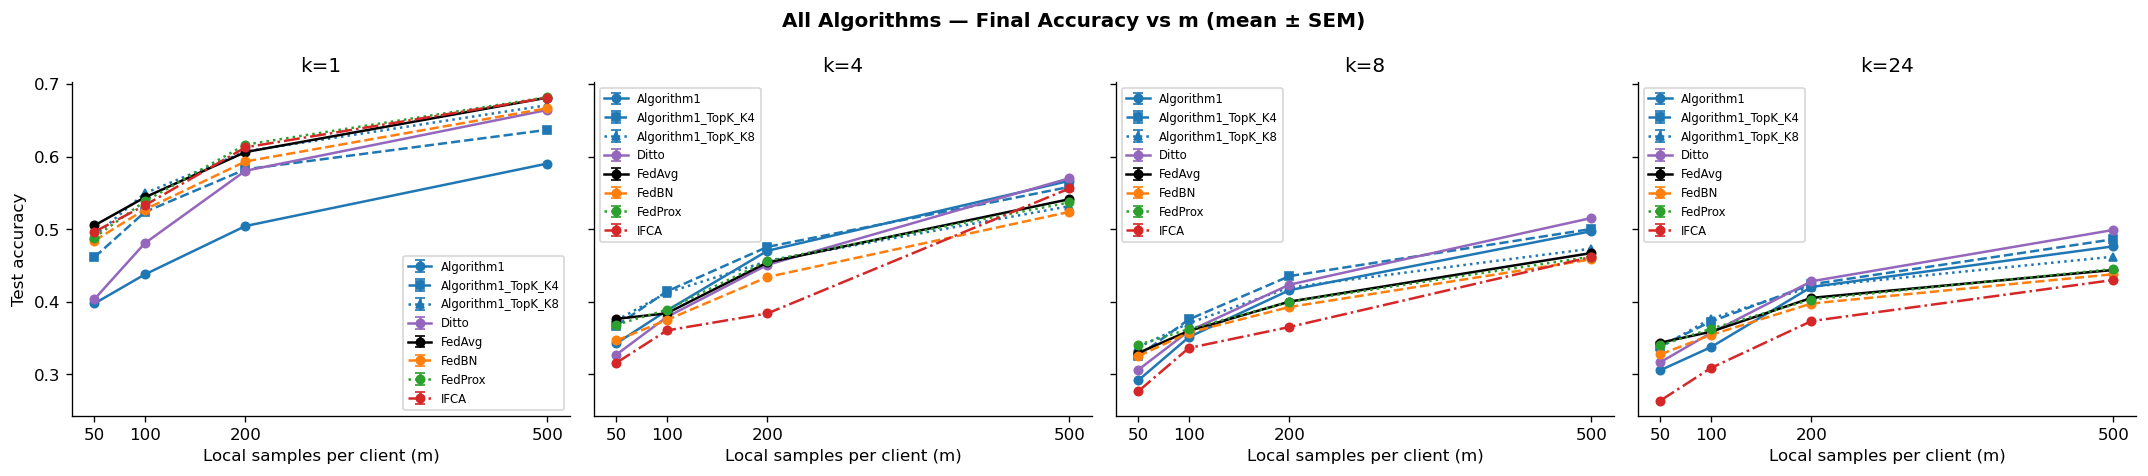

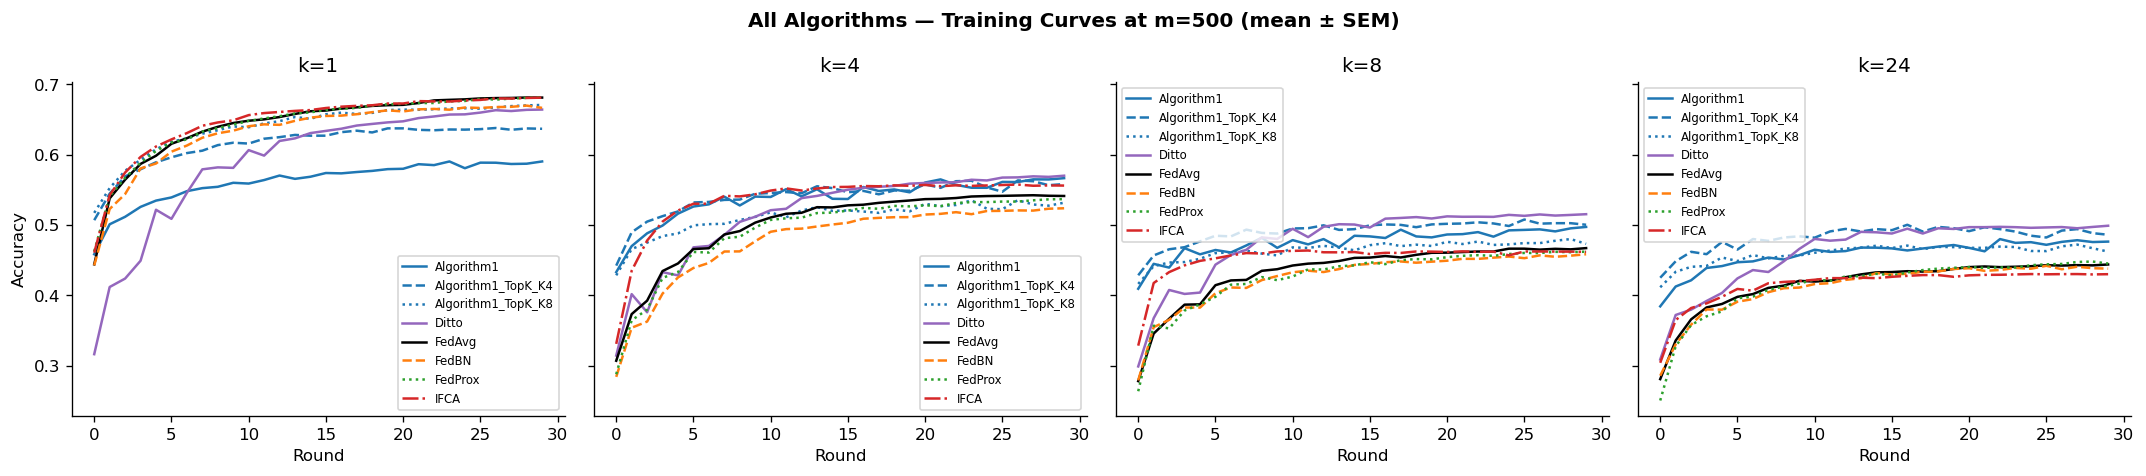


Final accuracy (mean ± SEM) — k=1


,m=50,m=100,m=200,m=500
algo,,,,
Algorithm1,0.3976 ± nan,0.4376 ± nan,0.5043 ± nan,0.5903 ± nan
Algorithm1_TopK_K4,0.4614 ± nan,0.5235 ± nan,0.5824 ± nan,0.6368 ± nan
Algorithm1_TopK_K8,0.4906 ± nan,0.5494 ± nan,0.6071 ± nan,0.6708 ± nan
Ditto,0.4036 ± nan,0.4806 ± nan,0.5804 ± nan,0.6642 ± nan
FedAvg,0.5051 ± nan,0.5438 ± nan,0.6062 ± nan,0.6812 ± nan
FedBN,0.4841 ± nan,0.5270 ± nan,0.5932 ± nan,0.6666 ± nan
FedProx,0.4885 ± nan,0.5383 ± nan,0.6164 ± nan,0.6818 ± nan
IFCA,0.4964 ± nan,0.5328 ± nan,0.6127 ± nan,0.6811 ± nan



Final accuracy (mean ± SEM) — k=4


,m=50,m=100,m=200,m=500
algo,,,,
Algorithm1,0.3427 ± nan,0.3878 ± nan,0.4703 ± nan,0.5666 ± nan
Algorithm1_TopK_K4,0.3671 ± nan,0.4142 ± nan,0.4756 ± nan,0.5582 ± nan
Algorithm1_TopK_K8,0.3745 ± nan,0.4125 ± nan,0.4559 ± nan,0.5317 ± nan
Ditto,0.3273 ± nan,0.3789 ± nan,0.4509 ± nan,0.5701 ± nan
FedAvg,0.3765 ± nan,0.3841 ± nan,0.4542 ± nan,0.5413 ± nan
FedBN,0.3467 ± nan,0.3750 ± nan,0.4340 ± nan,0.5238 ± nan
FedProx,0.3683 ± nan,0.3890 ± nan,0.4564 ± nan,0.5368 ± nan
IFCA,0.3160 ± nan,0.3605 ± nan,0.3839 ± nan,0.5560 ± nan



Final accuracy (mean ± SEM) — k=8


,m=50,m=100,m=200,m=500
algo,,,,
Algorithm1,0.2920 ± nan,0.3513 ± nan,0.4160 ± nan,0.4972 ± nan
Algorithm1_TopK_K4,0.3254 ± nan,0.3756 ± nan,0.4353 ± nan,0.5003 ± nan
Algorithm1_TopK_K8,0.3374 ± nan,0.3705 ± nan,0.4196 ± nan,0.4732 ± nan
Ditto,0.3065 ± nan,0.3595 ± nan,0.4235 ± nan,0.5153 ± nan
FedAvg,0.3296 ± nan,0.3598 ± nan,0.4002 ± nan,0.4671 ± nan
FedBN,0.3252 ± nan,0.3575 ± nan,0.3927 ± nan,0.4584 ± nan
FedProx,0.3407 ± nan,0.3623 ± nan,0.3997 ± nan,0.4621 ± nan
IFCA,0.2769 ± nan,0.3363 ± nan,0.3653 ± nan,0.4617 ± nan



Final accuracy (mean ± SEM) — k=24


,m=50,m=100,m=200,m=500
algo,,,,
Algorithm1,0.3058 ± nan,0.3374 ± nan,0.4204 ± nan,0.4763 ± nan
Algorithm1_TopK_K4,0.3391 ± nan,0.3726 ± nan,0.4240 ± nan,0.4861 ± nan
Algorithm1_TopK_K8,0.3376 ± nan,0.3767 ± nan,0.4207 ± nan,0.4621 ± nan
Ditto,0.3168 ± nan,0.3570 ± nan,0.4282 ± nan,0.4989 ± nan
FedAvg,0.3437 ± nan,0.3587 ± nan,0.4053 ± nan,0.4438 ± nan
FedBN,0.3276 ± nan,0.3543 ± nan,0.3976 ± nan,0.4379 ± nan
FedProx,0.3399 ± nan,0.3628 ± nan,0.4031 ± nan,0.4452 ± nan
IFCA,0.2640 ± nan,0.3087 ± nan,0.3734 ± nan,0.4300 ± nan


In [304]:
# ── Section 1.8: cnn_cifar10_m — All Algorithms Compared ───────────────────
import re as _re_mall
from pathlib import Path as _Path_mall

_M_ALL_BASE = _Path_mall('results/cnn_cifar10_m')
_M_ALL_PAT  = _re_mall.compile(r'cnn_cifar10_c(\d+)_m(\d+)_seed(\d+)\.csv')

_M_ALL_ALGOS = [
    'Algorithm1', 'Algorithm1_TopK_K4', 'Algorithm1_TopK_K8',
    'Ditto', 'FedAvg', 'FedBN', 'FedProx', 'IFCA',
]

_M_ALL_STYLE = {
    'Algorithm1':         dict(linestyle='-',  color='#1f77b4', marker='o'),
    'Algorithm1_TopK_K4': dict(linestyle='--', color='#1f77b4', marker='s'),
    'Algorithm1_TopK_K8': dict(linestyle=':',  color='#1f77b4', marker='^'),
    'FedAvg':             dict(linestyle='-',  color='k',       marker='o'),
    'FedBN':              dict(linestyle='--', color='#ff7f0e', marker='o'),
    'FedProx':            dict(linestyle=':',  color='#2ca02c', marker='o'),
    'IFCA':               dict(linestyle='-.', color='#d62728', marker='o'),
    'Ditto':              dict(linestyle='-',  color='#9467bd', marker='o'),
}

mall_frames = []
for _algo in _M_ALL_ALGOS:
    _p = _M_ALL_BASE / _algo
    if not _p.exists():
        continue
    for _f in sorted(_p.glob('*.csv')):
        _match = _M_ALL_PAT.search(_f.name)
        if not _match:
            continue
        _nc, _m, _seed = int(_match.group(1)), int(_match.group(2)), int(_match.group(3))
        _df = pd.read_csv(_f)
        _df['algo'] = _algo
        _df['data_n_clusters'] = _nc
        _df['m'] = _m
        _df['seed'] = _seed
        mall_frames.append(_df)

mall_data = pd.concat(mall_frames, ignore_index=True)

mall_stats = (
    mall_data
    .groupby(['algo', 'data_n_clusters', 'm', 'iter'])['accuracy']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
)
mall_stats['sem'] = mall_stats['std'] / mall_stats['n'].pow(0.5)

_mall_ks     = sorted(mall_data['data_n_clusters'].unique())
_mall_m_vals = sorted(mall_data['m'].unique())
_mall_algos  = [a for a in _M_ALL_ALGOS if a in mall_data['algo'].unique()]

# ── Final accuracy vs m — one panel per k ────────────────────────────────────
_mall_final = mall_stats[mall_stats['iter'] == mall_stats['iter'].max()].copy()

fig, axes = plt.subplots(1, len(_mall_ks), figsize=(4.5 * len(_mall_ks), 4), sharey=True)
if len(_mall_ks) == 1:
    axes = [axes]

for ax, nc in zip(axes, _mall_ks):
    for algo in _mall_algos:
        sub = _mall_final[
            (_mall_final['algo'] == algo) & (_mall_final['data_n_clusters'] == nc)
        ].sort_values('m')
        if sub.empty:
            continue
        style = _M_ALL_STYLE[algo]
        ax.errorbar(sub['m'], sub['mean'], yerr=sub['sem'],
                    label=algo, markersize=5, capsize=3, **style)
    ax.set_title(f'k={nc}')
    ax.set_xlabel('Local samples per client (m)')
    ax.set_xticks(_mall_m_vals)
    ax.legend(fontsize=7)

axes[0].set_ylabel('Test accuracy')
fig.suptitle('All Algorithms — Final Accuracy vs m (mean \u00b1 SEM)', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Training curves at largest m — one panel per k ───────────────────────────
_m_max = max(_mall_m_vals)

fig, axes = plt.subplots(1, len(_mall_ks), figsize=(4.5 * len(_mall_ks), 4), sharey=True)
if len(_mall_ks) == 1:
    axes = [axes]

for ax, nc in zip(axes, _mall_ks):
    for algo in _mall_algos:
        sub = mall_stats[
            (mall_stats['algo'] == algo) &
            (mall_stats['data_n_clusters'] == nc) &
            (mall_stats['m'] == _m_max)
        ].sort_values('iter')
        if sub.empty:
            continue
        style = _M_ALL_STYLE[algo]
        ax.plot(sub['iter'], sub['mean'], label=algo,
                linestyle=style['linestyle'], color=style['color'])
        ax.fill_between(sub['iter'],
                        sub['mean'] - sub['sem'],
                        sub['mean'] + sub['sem'],
                        alpha=0.15, color=style['color'])
    ax.set_title(f'k={nc}')
    ax.set_xlabel('Round')
    ax.legend(fontsize=7)

axes[0].set_ylabel('Accuracy')
fig.suptitle(f'All Algorithms — Training Curves at m={_m_max} (mean \u00b1 SEM)', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary table: final accuracy × (algo, m) at each k ─────────────────────
for _nc in _mall_ks:
    _sub = _mall_final[_mall_final['data_n_clusters'] == _nc].copy()
    _sub['acc'] = _sub.apply(lambda r: f"{r['mean']:.4f} \u00b1 {r['sem']:.4f}", axis=1)
    _piv = _sub.pivot_table(index='algo', columns='m', values='acc', aggfunc='first')
    _piv.columns = [f'm={c}' for c in _piv.columns]
    print(f'\nFinal accuracy (mean \u00b1 SEM) — k={_nc}')
    display(_piv)


### Within-Cluster Rotation Spread σ

In the standard rotated CIFAR-10 setup every client in a cluster receives exactly the cluster's centre angle. Here we blur that hard boundary: each client's rotation angle is sampled from $\mathcal{N}(\text{centre},\, \sigma^2)$, so neighbouring clusters overlap increasingly as σ grows.

- **σ = 0** — hard clusters, no overlap (original setting).  
- **σ = 15°** — mild spread, clusters still well-separated (centres 90° apart).  
- **σ = 30°** — moderate overlap; clients near cluster boundaries become ambiguous.  
- **σ = 45°** — heavy overlap; cluster structure is largely lost.  
- **σ = 60°** — near-uniform coverage; no meaningful cluster signal remains.

The plot shows **final-round test accuracy vs σ** (mean ± SEM over 10 seeds) for each algorithm. A method that degrades slowly with σ is robust to fuzzy cluster boundaries.

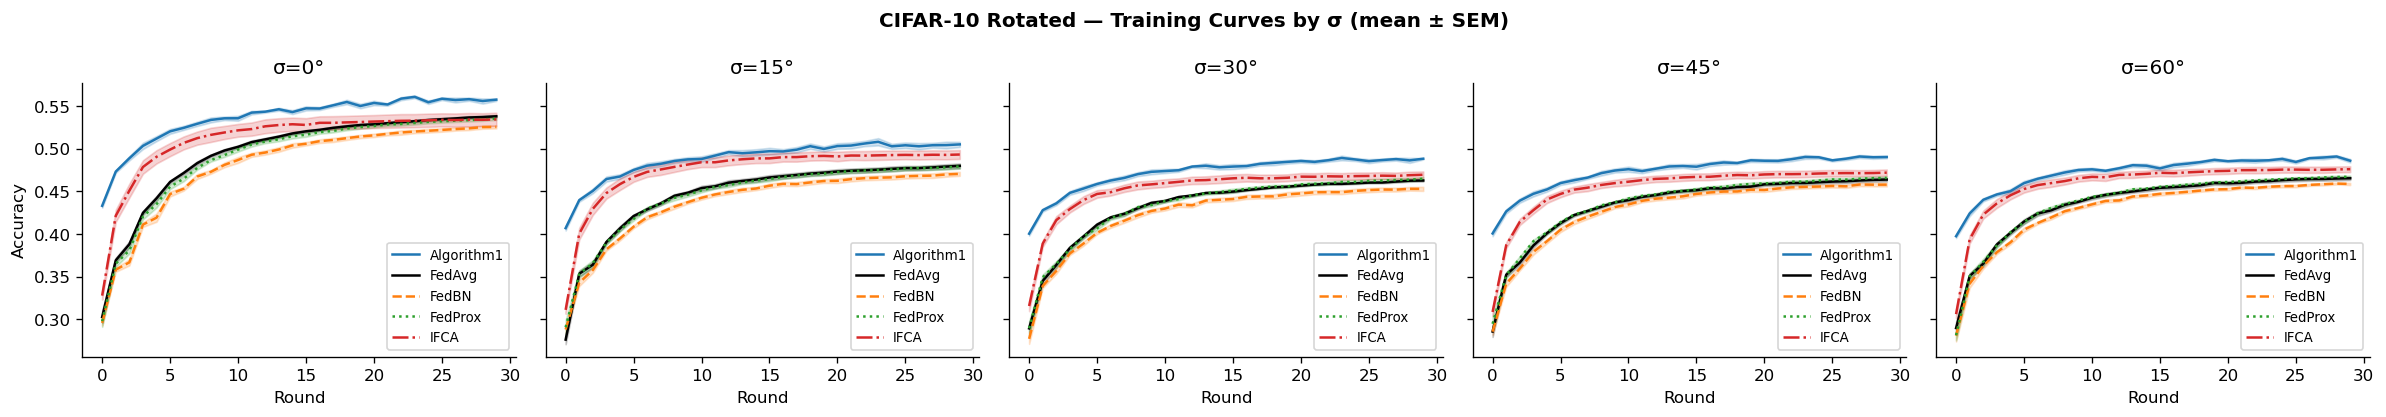

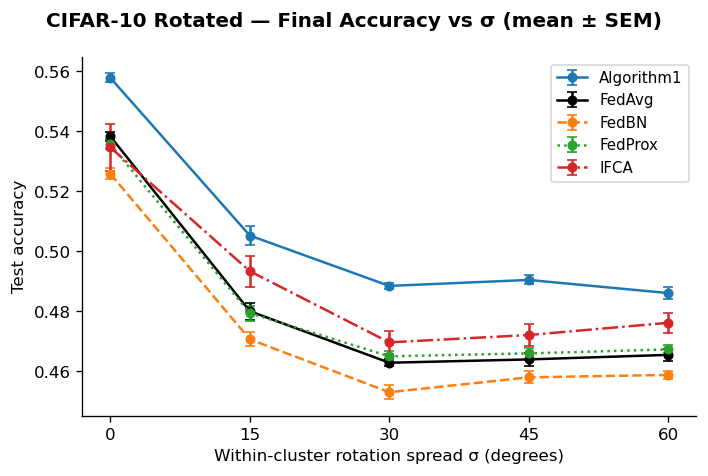

Final accuracy (mean ± SEM) — CIFAR-10 σ sweep


,σ=0,σ=15,σ=30,σ=45,σ=60
algo,,,,,
Algorithm1,0.5578 ± 0.0015,0.5052 ± 0.0030,0.4884 ± 0.0009,0.4904 ± 0.0015,0.4860 ± 0.0021
FedAvg,0.5383 ± 0.0015,0.4800 ± 0.0028,0.4628 ± 0.0012,0.4639 ± 0.0022,0.4654 ± 0.0020
FedBN,0.5258 ± 0.0019,0.4706 ± 0.0023,0.4530 ± 0.0024,0.4579 ± 0.0020,0.4587 ± 0.0013
FedProx,0.5356 ± 0.0017,0.4794 ± 0.0025,0.4650 ± 0.0018,0.4659 ± 0.0017,0.4673 ± 0.0013
IFCA,0.5346 ± 0.0078,0.4933 ± 0.0052,0.4696 ± 0.0039,0.4720 ± 0.0037,0.4761 ± 0.0034


In [232]:
# ── Section 9: Within-Cluster Rotation Spread σ ───────────────────────────────
SIGMA_BASE  = Path("results/cnn_cifar10_sigma")
SIGMA_ALGOS = ["Algorithm1", "FedAvg", "FedBN", "FedProx", "IFCA"]

sigma_data = load_results(SIGMA_BASE, SIGMA_ALGOS)
sigma_vals = sorted(sigma_data["data_sigma"].unique())

# mean ± SEM per (algo, sigma, iter) across seeds
sigma_stats = (
    sigma_data
    .groupby(["algo", "data_sigma", "iter"])["accuracy"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)
sigma_stats["sem"] = sigma_stats["std"] / sigma_stats["n"].pow(0.5)

# ── Training curves — one subplot per σ ──────────────────────────────────────
fig, axes = plt.subplots(1, len(sigma_vals), figsize=(4 * len(sigma_vals), 3.5), sharey=True)
if len(sigma_vals) == 1:
    axes = [axes]

for ax, sv in zip(axes, sigma_vals):
    for algo in SIGMA_ALGOS:
        sub = sigma_stats[
            (sigma_stats["algo"] == algo) & (sigma_stats["data_sigma"] == sv)
        ].sort_values("iter")
        if sub.empty:
            continue
        style = ALGO_STYLE[algo]
        ax.plot(sub["iter"], sub["mean"], label=algo, **style)
        ax.fill_between(
            sub["iter"],
            sub["mean"] - sub["sem"],
            sub["mean"] + sub["sem"],
            alpha=0.2, color=style["color"],
        )
    ax.set_title(f"σ={int(sv)}°")
    ax.set_xlabel("Round")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Accuracy")
fig.suptitle("CIFAR-10 Rotated — Training Curves by σ (mean ± SEM)", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Final accuracy vs σ ───────────────────────────────────────────────────────
final_sigma = sigma_stats[sigma_stats["iter"] == sigma_stats["iter"].max()].copy()

fig, ax = plt.subplots(figsize=(6, 4))
for algo in SIGMA_ALGOS:
    sub = final_sigma[final_sigma["algo"] == algo].sort_values("data_sigma")
    if sub.empty:
        continue
    style = ALGO_STYLE[algo]
    ax.errorbar(
        sub["data_sigma"], sub["mean"],
        yerr=sub["sem"],
        label=algo, marker="o", markersize=5, capsize=3,
        **style,
    )
ax.set_xlabel("Within-cluster rotation spread σ (degrees)")
ax.set_ylabel("Test accuracy")
ax.set_xticks(sigma_vals)
ax.legend(fontsize=9)
fig.suptitle("CIFAR-10 Rotated — Final Accuracy vs σ (mean ± SEM)", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
final_sigma["acc"] = final_sigma.apply(
    lambda r: f"{r['mean']:.4f} ± {r['sem']:.4f}", axis=1
)
pivot_sigma = final_sigma.pivot_table(
    index="algo", columns="data_sigma", values="acc", aggfunc="first"
)
pivot_sigma.columns = [f"σ={int(c)}" for c in pivot_sigma.columns]
print("Final accuracy (mean ± SEM) — CIFAR-10 σ sweep")
display(pivot_sigma)

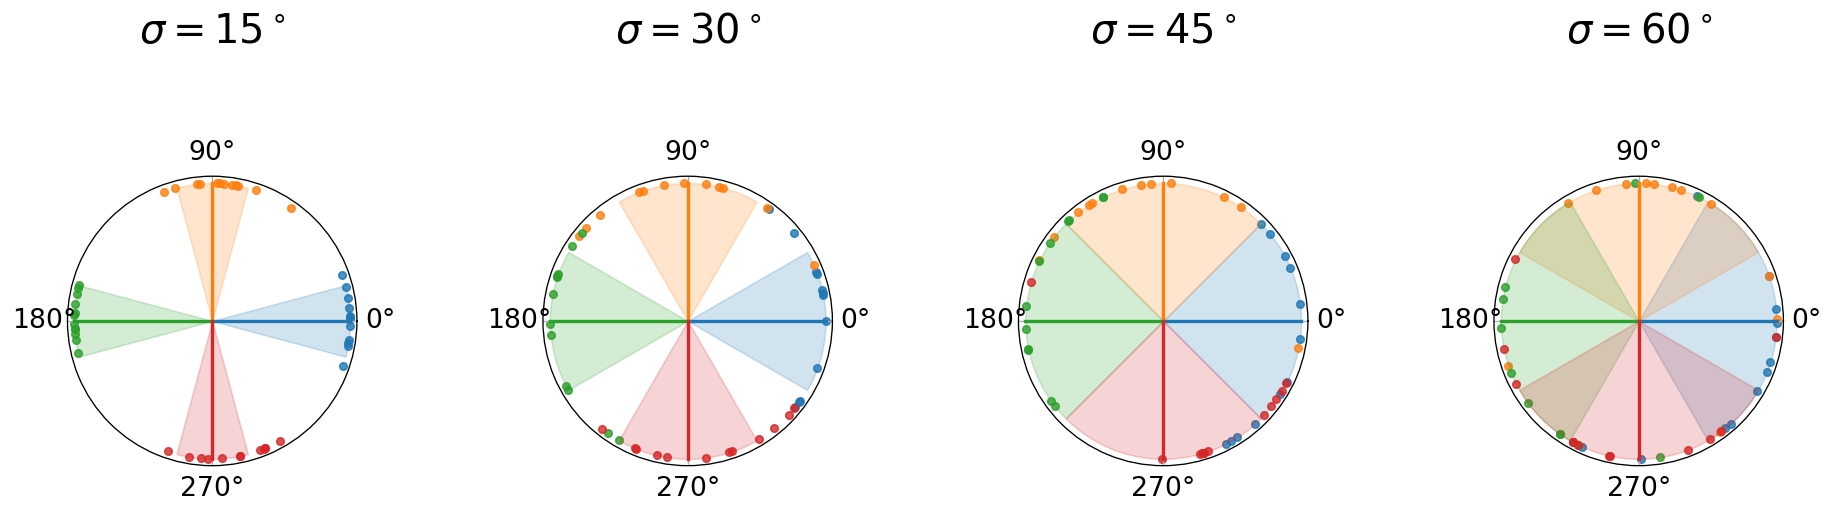

In [233]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sigma_effect(n_clusters=4, sigmas=[15, 30, 45, 60], seed=0):
    """
    Visualize how sigma affects overlap of cluster rotations on a circle.
    Each subplot shows cluster centers and ±sigma spread as sectors.
    """
    rng = np.random.default_rng(seed)

    # Cluster centers
    n_sector = 360 // n_clusters
    angles = [0, 90, 180, 270]
    centers_deg = np.array([i * n_sector for i in range(n_clusters)])
    centers_rad = np.deg2rad(centers_deg)

    fig, axes = plt.subplots(1, len(sigmas), figsize=(4 * len(sigmas), 4),
                             subplot_kw={'projection': 'polar'})

    if len(sigmas) == 1:
        axes = [axes]

    for ax, sigma in zip(axes, sigmas):
        ax.set_title(f"$\\sigma = {sigma}^\\circ$", fontsize=24, pad=80)
        ax.set_theta_zero_location("E")   # 0° on right
        ax.set_theta_direction(1)        # clockwise
        ax.set_yticks([])
        ax.tick_params(axis='x', labelsize=16)  # increase angle label size
        ax.set_thetagrids(angles, labels=[f"{a}°" for a in angles])

        cmap = plt.get_cmap("tab10")  # or "tab20", "Set2", etc.
        for cluster_id, (c_deg, c_rad) in enumerate(zip(centers_deg, centers_rad)):
        
            color = cmap(cluster_id)
        
            if sigma == 0:
                ax.plot([c_rad, c_rad], [0, 1], linewidth=2, color=color)
            else:
                spread = np.deg2rad(sigma)
                theta = np.linspace(c_rad - spread, c_rad + spread, 100)
        
                # Sector
                ax.fill_between(theta, 0, 1, color=color, alpha=0.2)
                ax.plot([c_rad, c_rad], [0, 1], linewidth=2, color=color)
        
            # --- Samples ---
            n_clients = 50
        
            if sigma == 0:
                samples = np.full(n_clients // n_clusters, c_deg)
            else:
                samples = rng.normal(c_deg, sigma, n_clients // n_clusters)
        
            samples_rad = np.deg2rad(samples % 360)
        
            ax.scatter(
                samples_rad,
                np.ones_like(samples_rad),
                s=20,
                color=color,       # ← match sector color
                alpha=0.8
            )
    plt.tight_layout()
    plt.savefig("sigma_circular_plot.pdf", dpi=300, bbox_inches="tight")
    plt.show()

# Run it
plot_sigma_effect()

---

## Part 3 — Distribution Shift

### CIFAR-10 Rotated with Sudden Distribution Shift

At round `shift_at`, the second half of each cluster's clients move to a new rotation angle (midpoint between their original cluster centre and the next). Both training and test data are replaced to reflect the new distribution. A method that recovers quickly post-shift adapts well to non-stationary distributions.

In [317]:
# ── Load cnn_cifar10_shift results ────────────────────────────────────────────
import re as _re_shift

SHIFT_BASE  = Path("results/cnn_cifar10_shift")
SHIFT_ALGOS = ["Algorithm1", "Algorithm1_TopK",  "FedAvg", "FedBN", "FedProx", "IFCA", "Ditto"]
_PAT_SHIFT  = _re_shift.compile(r"cnn_cifar10_shift(\d+)_seed(\d+)\.csv")

shift_frames = []
for algo in SHIFT_ALGOS:
    p = SHIFT_BASE / algo
    if not p.exists():
        continue
    for f in sorted(p.glob("*.csv")):
        m = _PAT_SHIFT.search(f.name)
        if not m:
            continue
        df             = pd.read_csv(f)
        df["algo"]     = algo
        df["shift_at"] = int(m.group(1))
        df["seed"]     = int(m.group(2))
        shift_frames.append(df)

shift_data = pd.concat(shift_frames, ignore_index=True)

shift_stats = (
    shift_data
    .groupby(["algo", "shift_at", "iter"])["accuracy"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)
shift_stats["sem"] = shift_stats["std"] / shift_stats["n"].pow(0.5)

shift_vals = sorted(shift_data["shift_at"].unique())

print(f"Loaded {len(shift_frames)} files")
print(f"  algos    : {sorted(shift_data['algo'].unique())}")
print(f"  shift_at : {shift_vals}")
print(f"  seeds    : {sorted(shift_data['seed'].unique())}")
print(f"  rounds   : {sorted(shift_data['iter'].unique())}")

Loaded 28 files
  algos    : ['Algorithm1', 'Algorithm1_TopK', 'Ditto', 'FedAvg', 'FedBN', 'FedProx', 'IFCA']
  shift_at : [5, 10, 15, 20]
  seeds    : [0, 1, 2, 3, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
  rounds   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


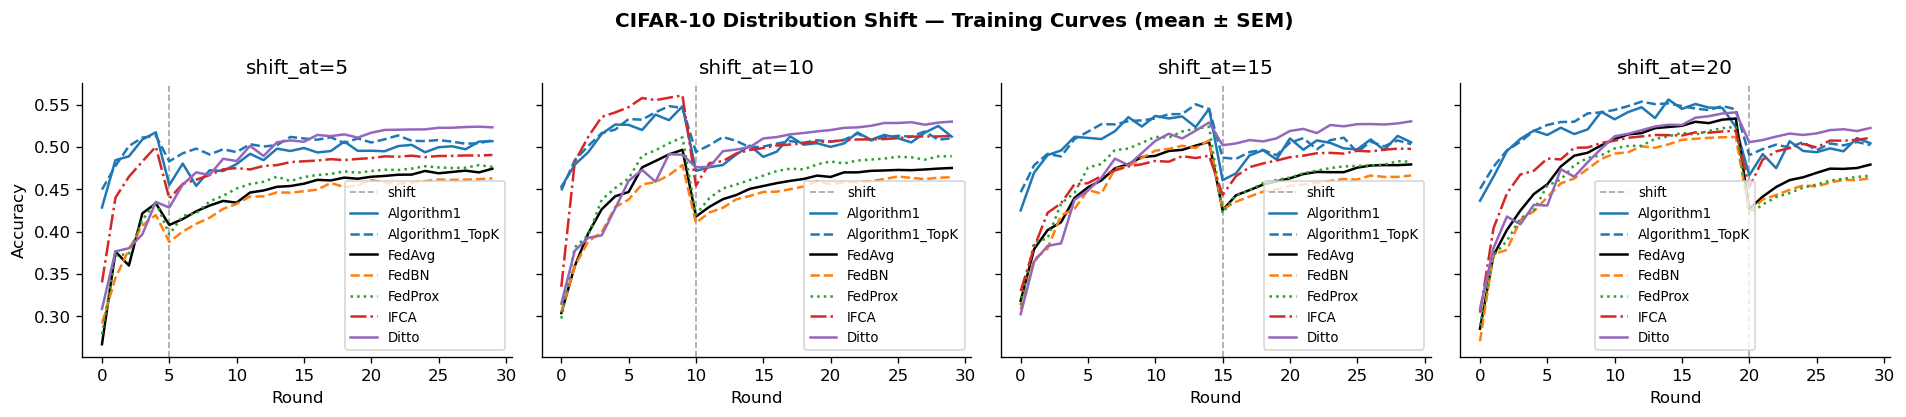

Final accuracy (mean ± SEM) — CIFAR-10 Distribution Shift


,shift_at=5,shift_at=10,shift_at=15,shift_at=20
algo,,,,
Algorithm1,0.5068 ± nan,0.5120 ± nan,0.5055 ± nan,0.5042 ± nan
Algorithm1_TopK,0.5078 ± nan,0.5103 ± nan,0.5033 ± nan,0.5022 ± nan
FedAvg,0.4742 ± nan,0.4750 ± nan,0.4792 ± nan,0.4791 ± nan
FedBN,0.4628 ± nan,0.4642 ± nan,0.4662 ± nan,0.4632 ± nan
FedProx,0.4763 ± nan,0.4889 ± nan,0.4825 ± nan,0.4660 ± nan
IFCA,0.4905 ± nan,0.5129 ± nan,0.4976 ± nan,0.5107 ± nan
Ditto,0.5231 ± nan,0.5298 ± nan,0.5302 ± nan,0.5223 ± nan


In [318]:
# ── Plot: training curves — one subplot per shift_at ─────────────────────────
fig, axes = plt.subplots(1, len(shift_vals), figsize=(4 * len(shift_vals), 3.5), sharey=True)
if len(shift_vals) == 1:
    axes = [axes]

for ax, sv in zip(axes, shift_vals):
    ax.axvline(sv, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="shift")
    for algo in SHIFT_ALGOS:
        sub = shift_stats[
            (shift_stats["algo"] == algo) & (shift_stats["shift_at"] == sv)
        ].sort_values("iter")
        if sub.empty:
            continue
        style = ALGO_STYLE[algo]
        ax.plot(sub["iter"], sub["mean"], label=algo, **style)
        ax.fill_between(
            sub["iter"],
            sub["mean"] - sub["sem"],
            sub["mean"] + sub["sem"],
            alpha=0.2, color=style["color"],
        )
    ax.set_title(f"shift_at={sv}")
    ax.set_xlabel("Round")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Accuracy")
fig.suptitle("CIFAR-10 Distribution Shift — Training Curves (mean ± SEM)", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Summary table: final accuracy by algo × shift_at ─────────────────────────
_end = shift_stats["iter"].max()
_final = shift_stats[shift_stats["iter"] == _end].copy()
_final["acc"] = _final.apply(lambda r: f"{r['mean']:.4f} ± {r['sem']:.4f}", axis=1)
_pivot = _final.pivot_table(index="algo", columns="shift_at", values="acc", aggfunc="first")
_pivot.columns = [f"shift_at={c}" for c in _pivot.columns]
_pivot = _pivot.reindex([a for a in SHIFT_ALGOS if a in _pivot.index])
print("Final accuracy (mean ± SEM) — CIFAR-10 Distribution Shift")
display(_pivot)